<a href="https://colab.research.google.com/github/abhishekanand04/Intro-to-ML-and-NN/blob/machinelearning/CM2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

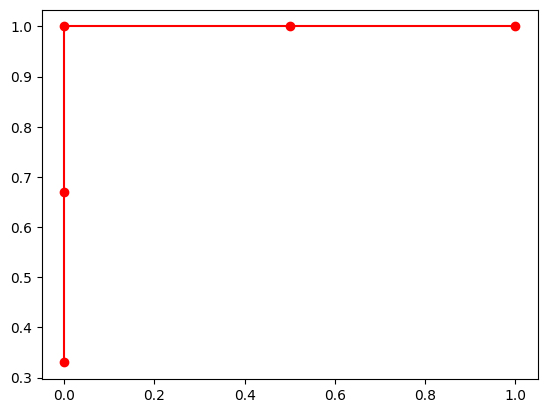

In [ ]:
import matplotlib.pyplot as plt

FPR = [0,   0,   0,0.5, 1]
TPR = [0.33,0.67,1, 1,  1]
plt.plot(FPR,TPR,color='red' ,marker='o')


AUC  1.0


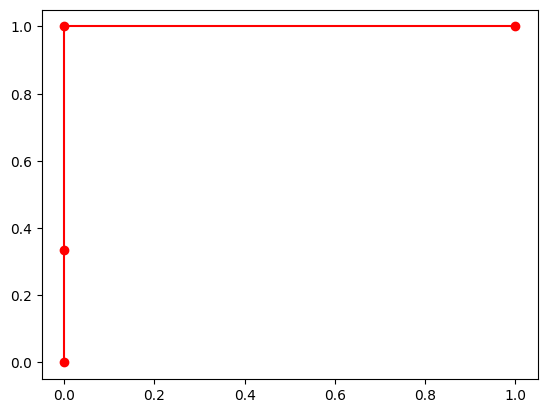

In [ ]:

from sklearn.metrics import roc_curve, roc_auc_score

y_test = [1,1,1,0,0]
y_prob = [0.9,0.8,0.7,0.6,0.3]
fpr, tpr, thr = roc_curve(y_test,y_prob)
auc = roc_auc_score(y_test,y_prob)
print("AUC ",auc)
plt.plot(fpr,tpr,color='red' ,marker='o')

AUC  0.8333333333333333


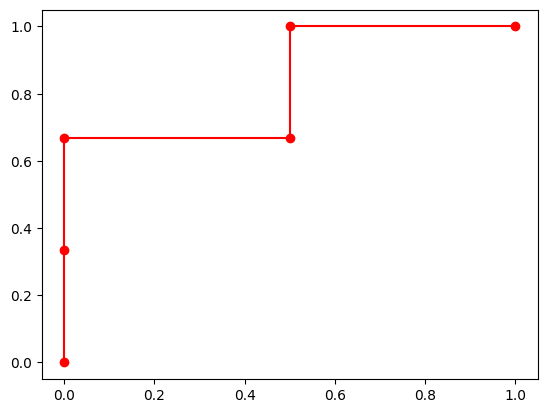

In [ ]:
from sklearn.metrics import roc_curve, roc_auc_score

y_test = [1,1,0,1,0]
y_prob = [0.9,0.8,0.7,0.6,0.3]
fpr2, tpr2, thr = roc_curve(y_test,y_prob)
auc = roc_auc_score(y_test,y_prob)
print("AUC ",auc)
plt.plot(fpr2,tpr2,color='red' ,marker='o')

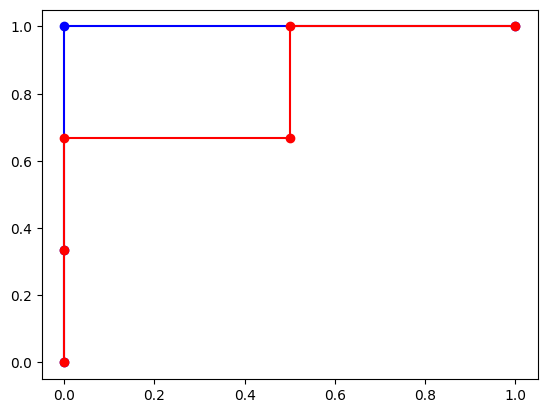

In [ ]:
plt.plot(fpr,tpr,color='blue' ,marker='o')
plt.plot(fpr2,tpr2,color='red' ,marker='o')

Downloading...
From: https://drive.google.com/uc?id=1dw56R8SzKgTgiKurfBLUTxmiewJacMkt
To: /content/Spam_finalData.csv
100% 1.64M/1.64M [00:00<00:00, 148MB/s]


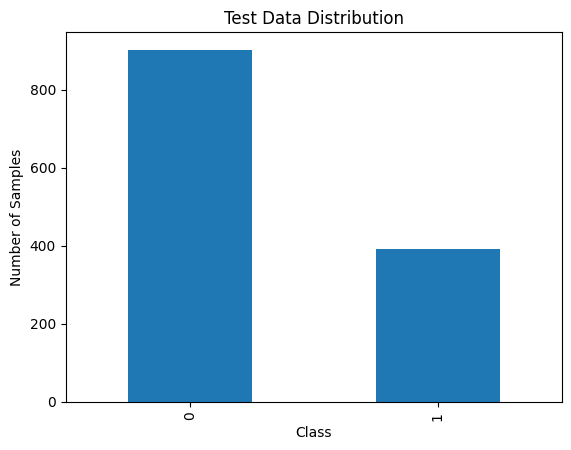

Training Data:(3878, 15),(3878,), Testing Data: (1293, 15),(1293,)


LogisticRegression()

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split

!gdown 1dw56R8SzKgTgiKurfBLUTxmiewJacMkt

dt = pd.read_csv('Spam_finalData.csv')




X_train,X_test,y_train,y_test = train_test_split(dt.drop(['label_num'],axis=1),dt['label_num'])

y_test.value_counts().plot(kind='bar')
plt.xlabel('Class')
plt.ylabel('Number of Samples')
plt.title('Test Data Distribution')
plt.show()


print(f'Training Data:{X_train.shape},{y_train.shape}, Testing Data: {X_test.shape},{y_test.shape}')





model = LogisticRegression()
model.fit(X_train,y_train)


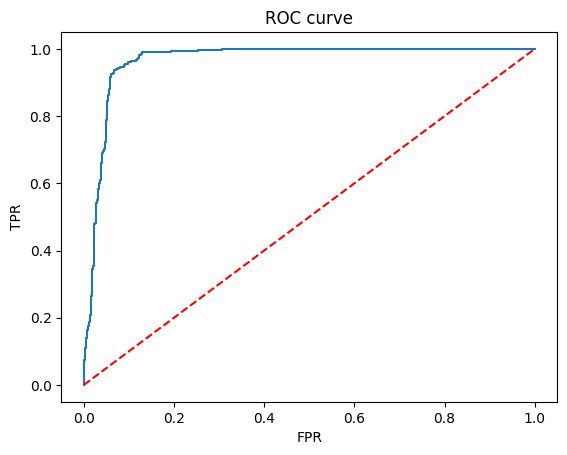

In [ ]:
from sklearn.metrics import roc_curve, roc_auc_score
probability = model.predict_proba(X_test)
probabilites = probability[:,1]
fpr, tpr, thr = roc_curve(y_test,probabilites)
plt.plot(fpr,tpr)

#random model
plt.plot(fpr,fpr,'--',color='red' )
plt.title('ROC curve')
plt.xlabel('FPR')
plt.ylabel('TPR')
plt.show()

In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import f1_score
from imblearn.over_sampling import SMOTE

# Create an instance of SMOTE
smt = SMOTE()


# Perform SMOTE on the training data
print('Before SMOTE')
print(y_train.value_counts())

X_sm, y_sm = smt.fit_resample(X_train, y_train)
print('After Oversampling')
print(y_sm.value_counts())


Before SMOTE
label_num
0    2770
1    1108
Name: count, dtype: int64
After Oversampling
label_num
1    2770
0    2770
Name: count, dtype: int64
